<a href="https://colab.research.google.com/github/cemilkaracam/Haar-Wavelet-Regularized-Approximation-of-Discontinuous-Functions/blob/main/APPEND%C4%B0X_F.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

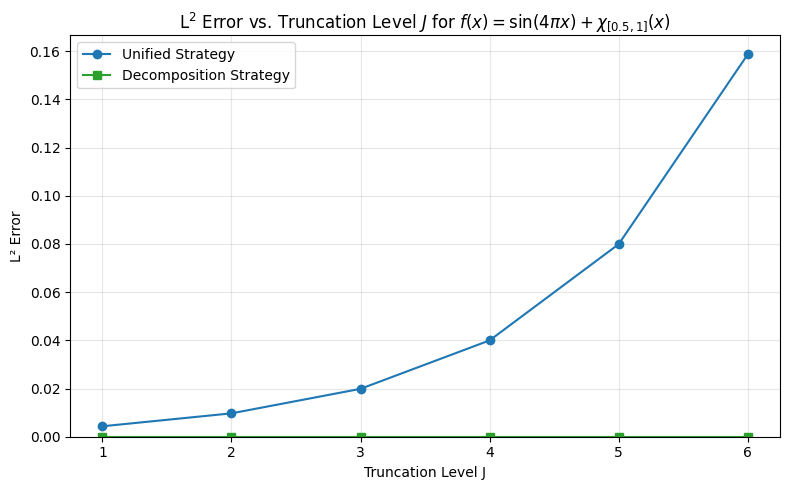

In [ ]:
# Gerekli paketler (Colab'da bir kez çalıştırın)
!pip install pywavelets matplotlib -q

import numpy as np
import pywt
import matplotlib.pyplot as plt

# Sürekli ve basamak fonksiyonları
def f_continuous(x):
    return np.sin(4 * np.pi * x)

def f_discontinuous(x):
    return (x >= 0.5).astype(float)

def f_total(x):
    return f_continuous(x) + f_discontinuous(x)

# Haar regularizasyon: sadece approximation katsayısı bırakılır
def haar_regularize(signal, level=3, mode='symmetric'):
    coeffs = pywt.wavedec(signal, 'haar', level=level, mode=mode)
    coeffs_trunc = [coeffs[0]] + [np.zeros_like(c) for c in coeffs[1:]]
    rec = pywt.waverec(coeffs_trunc, 'haar', mode=mode)
    return rec[:len(signal)]

# Dyadik grid (endpoint=False ile 1024 nokta)
x = np.linspace(0, 1, 1024, endpoint=False)
dx = x[1] - x[0]
f_true = f_total(x)

# J=1..6 için L2 hata hesapları
levels = list(range(1, 7))
errors_unified = []
errors_decomp = []

for J in levels:
    # Unified strategy: tam fonksiyona Haar
    f_unified = haar_regularize(f_true, level=J)
    err_u = np.sqrt(np.sum((f_true - f_unified)**2) * dx)
    errors_unified.append(err_u)

    # Decomposition strategy: sadece basamak fonksiyonuna Haar, sinüs korunur
    f_d_smooth = haar_regularize(f_discontinuous(x), level=J)
    f_decomp = f_continuous(x) + f_d_smooth
    err_d = np.sqrt(np.sum((f_true - f_decomp)**2) * dx)
    errors_decomp.append(err_d)

# Grafik
plt.figure(figsize=(8, 5))
plt.plot(levels, errors_unified, 'o-', color='tab:blue', label='Unified Strategy')
plt.plot(levels, errors_decomp, 's-', color='tab:green', label='Decomposition Strategy')
plt.xlabel('Truncation Level J')
plt.ylabel('L² Error')
plt.title(r'L$^{2}$ Error vs. Truncation Level $J$ for $f(x)=\sin(4\pi x)+\chi_{[0.5,1]}(x)$')
plt.xticks(levels)
plt.ylim(bottom=0)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()
